In [3]:
import pandas as pd
import datetime
import matplotlib.pyplot as plt

In [4]:
# data from: https://www.kaggle.com/datasets/novandraanugrah/nasdaq-100-nas100-historical-price-data/data
# keep only 1m_data.csv
# rename 1m_data.csv -> NAS100_1min_ETH.csv

In [5]:
# prep_data.py
def preprocess_data(input_filepath, start_date):
    df = pd.read_csv(input_filepath, sep="\t")
    df.columns = df.columns.str.lower()

    df['datetime'] = pd.to_datetime(df['datetime'], format='%Y.%m.%d %H:%M:%S')
    # weird fix?????
    df['datetime'] = df['datetime'].dt.tz_localize('EET', ambiguous='NaT', nonexistent='shift_forward').dt.tz_convert('America/New_York')
    df.set_index('datetime', inplace=True)
    df = df.sort_index()

    df = df.loc[start_date:]
    df_rth = df.between_time("09:30", "16:00").copy()

    # ensure only valid sessions are left, server outages might occur
    daily_counts = df_rth.groupby(df_rth.index.normalize()).size()
    valid_dates = daily_counts[daily_counts >= 350].index
    df_rth = df_rth[df_rth.index.normalize().isin(valid_dates)]

    ohlc_cols = ['open', 'high', 'low', 'close']
    df_rth = df_rth[ohlc_cols].astype('float32')

    df_rth.to_csv('NAS100_1min_RTH.csv')
    df_rth.to_parquet('NAS100_1min_RTH.parquet')

    print(f"Processing complete!")
    print(f"Total RTH bars saved: {len(df_rth)}")

    return df_rth

In [6]:
# preprocess_data("NAS100_1min_ETH.csv", "2021-06-01")

In [13]:
# session.py

class Session:
    def __init__(self, file_path="NAS100_1min_RTH.parquet"):
        if file_path.endswith(".csv"):
            self.rth_df = pd.read_csv(file_path, index_col=0, dtype={'open': 'float32', 'high': 'float32', 'low': 'float32', 'close': 'float32'})
            self.rth_df.index = pd.to_datetime(self.rth_df.index, utc=True).tz_convert('America/New_York')
        elif file_path.endswith(".parquet"):
            self.rth_df = pd.read_parquet(file_path, engine="pyarrow")
        else:
            raise ValueError("File extension not supported!")
        self.sessions = [group for _, group in self.rth_df.groupby(self.rth_df.index.date)]
        self.dates = {index: date for index, (date, _) in enumerate(self.rth_df.groupby(self.rth_df.index.date))}

    def __len__(self):
        return len(self.sessions)

    def index_to_date(self, idx):
        date = self.dates.get(idx)
        if date is None:
            raise IndexError(f"Index not valid, might be under or over {len(self.sessions)}")
        return date

    def date_to_index(self, date: datetime.date):
        return list(self.dates.values()).index(date)  # O(N), not the time complexity I wanted but would have taken more mem complexity

    def get_dates(self):
        return list(self.dates.values())

    def get_session(self, idx):
        """
        :param idx:
        :return: A pandas dataframe of the open, low, high, close, volume from 9:30 to 16:00 EST
        """
        if idx >= len(self.sessions):
            raise IndexError(f"Index out of bounds, can only index up to less than {len(self.sessions)}")
        return self.sessions[idx]


In [14]:
# orb.py
from typing import Optional
from dataclasses import dataclass


@dataclass
class Trade:
    entry_time: pd.Timestamp
    entry_price: float
    direction: str  # long or short
    stop_loss: float
    take_profit: float
    orb_high: float
    orb_low: float
    orb_range: float

    exit_time: Optional[pd.Timestamp] = None
    exit_price: Optional[float] = None
    exit_reason: Optional[str] = None  # TP, SL, EOD (end of day)
    pnl_points: Optional[float] = None  # blended per-unit PnL
    pnl: Optional[float] = None # real pnl based on the set number of micro contracts
    result: Optional[str] = None  # "WIN" / "LOSS" (selling for 0 profit (breakeven) is considered a loss)

    market_return: Optional[float] = None

    def to_dict(self) -> dict:
        return {
            "entry_time": self.entry_time,
            "entry_price": self.entry_price,
            "direction": self.direction,
            "stop_loss": self.stop_loss,
            "take_profit": self.take_profit,
            "orb_high": self.orb_high,
            "orb_low": self.orb_low,
            "orb_range": self.orb_range,
            "exit_time": self.exit_time,
            "exit_price": self.exit_price,
            "exit_reason": self.exit_reason,
            "pnl_points": self.pnl_points,
            "pnl": self.pnl,
            "market_return": self.market_return,
            "result": self.result}


class ORB:
    def __init__(self, session: Session, micro_contracts=10):
        self.session = session

        self.RR = 2.50
        self.SL_factor = 1.00  # SL will be in the 100% of the range

        # each micro contract (MNQ) leveraged by 2x, for a fill mini-contract or (NQ) it's 20x leverage
        self.micro_contracts = micro_contracts

    def enter_trade(self, ts, open, low, high, close, orb_low, orb_high, direction: str) -> Trade:
        orb_range = orb_high - orb_low

        sl_distance = orb_range * self.SL_factor  # = 1.0 * range
        tp_distance = self.RR * sl_distance  # = 2.0 * range
        stop_loss = close - sl_distance * (1 if direction == "long" else -1)
        take_profit = close + tp_distance * (1 if direction == "long" else -1)

        return Trade(
            entry_time=ts,
            entry_price=close,
            direction=direction,
            stop_loss=stop_loss,
            orb_low=orb_low,
            orb_high=orb_high,
            orb_range=orb_range,
            take_profit=take_profit)

    def exit_trade(self, trade: Trade, exit_ts, exit_price, exit_reason):
        trade.exit_time = exit_ts
        trade.exit_reason = exit_reason

        if trade.direction == "long":
            trade.pnl_points = exit_price - trade.entry_price
            trade.pnl = trade.pnl_points * self.micro_contracts * 2
        else:
            trade.pnl_points = (trade.entry_price - exit_price)
            trade.pnl = trade.pnl_points * self.micro_contracts * 2

        if trade.pnl_points <= 0:
            trade.result = "LOSS"
        else:
            trade.result = "WIN"
        return trade

    def get_trade(self, df):
        orb_bars = df.between_time("9:30", "9:44")

        orb_high = max(orb_bars["high"])
        orb_low = min(orb_bars["low"])
        orb_range = orb_high - orb_low

        if not (20 <= orb_range <= 150):  # filter out orb ranges that are too small or too big
            return None

        forward_bars = df.between_time("9:45", "16:00")

        trade = None
        for ts, (open, high, low, close) in forward_bars.iterrows():
            if trade is None:  # find entry
                if close < orb_low:  # short
                    trade = self.enter_trade(ts, open, low, high, close, orb_low, orb_high, "short")
                elif close > orb_high:
                    trade = self.enter_trade(ts, open, low, high, close, orb_low, orb_high, "long")
            else:  # EOD exit
                if ts > ts.replace(hour=15, minute=55):
                    trade = self.exit_trade(trade, ts, close, exit_reason="EOD")
                    break

                if trade.direction == "long":
                    if low <= trade.stop_loss:
                        self.exit_trade(trade, ts, trade.stop_loss, "SL")
                        break
                    elif high >= trade.take_profit:
                        self.exit_trade(trade, ts, trade.take_profit, "TP")
                        break
                elif trade.direction == "short":
                    if high >= trade.stop_loss:
                        self.exit_trade(trade, ts, trade.stop_loss, "SL")
                        break
                    elif low <= trade.take_profit:
                        self.exit_trade(trade, ts, trade.take_profit, "TP")
                        break

        if trade is not None:
            if trade.exit_time is None:
                last_ts = forward_bars.index[-1]
                last_close = forward_bars['close'].iloc[-1]
                self.exit_trade(trade, last_ts, last_close, exit_reason="FORCE_CLOSE")
            trade.market_return = (df["close"].iloc[-1] - df["open"].iloc[0]) / df["open"].iloc[0]

        return trade

    def get_all_trades(self):
        trades = []
        for idx in range(len(self.session)):
            df = self.session.get_session(idx)
            trade = self.get_trade(df)
            if trade is not None:
                trades.append(trade)
        trades_df = pd.DataFrame([t.to_dict() for t in trades])
        return trades, trades_df


In [20]:
# create a session and get all the trades from the ORB
session = Session("NAS100_1min_RTH.csv")

# use parquet file for faster loading and operating
# session = Session("NAS100_1min_RTH.csv")

print("An example session:")
print(session.get_session(0).head())

orb = ORB(session, micro_contracts=10) # 10 micros = 1 mini (NQ)
trades, trades_df = orb.get_all_trades()

print("\nFirst trade:")
print(trades_df.iloc[0]) # get some information about the trades

An example session:
                                   open          high           low  \
datetime                                                              
2021-06-01 09:30:00-04:00  13757.000000  13765.000000  13750.299805   
2021-06-01 09:31:00-04:00  13758.000000  13760.299805  13753.000000   
2021-06-01 09:32:00-04:00  13756.000000  13756.299805  13748.000000   
2021-06-01 09:33:00-04:00  13751.299805  13753.299805  13745.500000   
2021-06-01 09:34:00-04:00  13752.299805  13755.799805  13749.299805   

                                  close  
datetime                                 
2021-06-01 09:30:00-04:00  13758.000000  
2021-06-01 09:31:00-04:00  13755.299805  
2021-06-01 09:32:00-04:00  13751.299805  
2021-06-01 09:33:00-04:00  13752.500000  
2021-06-01 09:34:00-04:00  13751.299805  

First trade:
entry_time       2021-06-01 09:48:00-04:00
entry_price                   13743.299805
direction                            short
stop_loss                     13775.099609
ta

In [39]:
# plot_equity.py
def plot_equity_curve(trades_df, mode="pnl_points"):
    cumulative_pnl = trades_df[mode].cumsum()  # calc the cumulative PNL
    trade_numbers = range(1, len(cumulative_pnl) + 1)

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot the equity curve
    ax.plot(trade_numbers, cumulative_pnl, marker='o', linestyle='-', color='royalblue', markersize=4,
            label=f"Cumulative PnL {'points' if mode == 'pnl_points' else ''}")

    # add horizontal line at zero for reference
    ax.axhline(0, color='black', linewidth=1, linestyle='--')

    # Add the area between the line and zero to highlight drawdowns vs profits
    ax.fill_between(trade_numbers, cumulative_pnl, 0, where=(cumulative_pnl >= 0), color='green', alpha=0.1)
    ax.fill_between(trade_numbers, cumulative_pnl, 0, where=(cumulative_pnl < 0), color='red', alpha=0.1)

    title = f"Equity Curve: Cumulative PnL {'points ' if mode == 'pnl_points' else ''}over Number of Trades"
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Trade Number", fontsize=12)
    ax.set_ylabel(f"Total PnL {'(Points)' if mode == 'pnl_points' else ''}", fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()

    plt.tight_layout()
    # plt.savefig(f"Equity_curve_pnl{'_points' if mode == 'pnl_points' else ''}.png")
    plt.show()

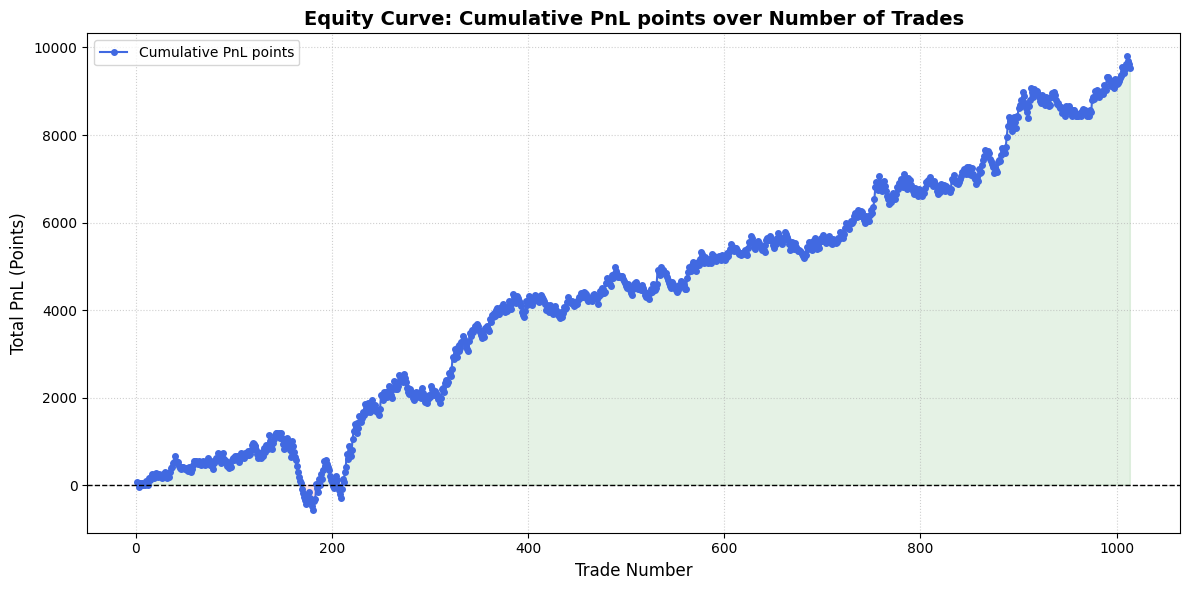

In [40]:
plot_equity_curve(trades_df, mode="pnl_points") # raw pnl points graph

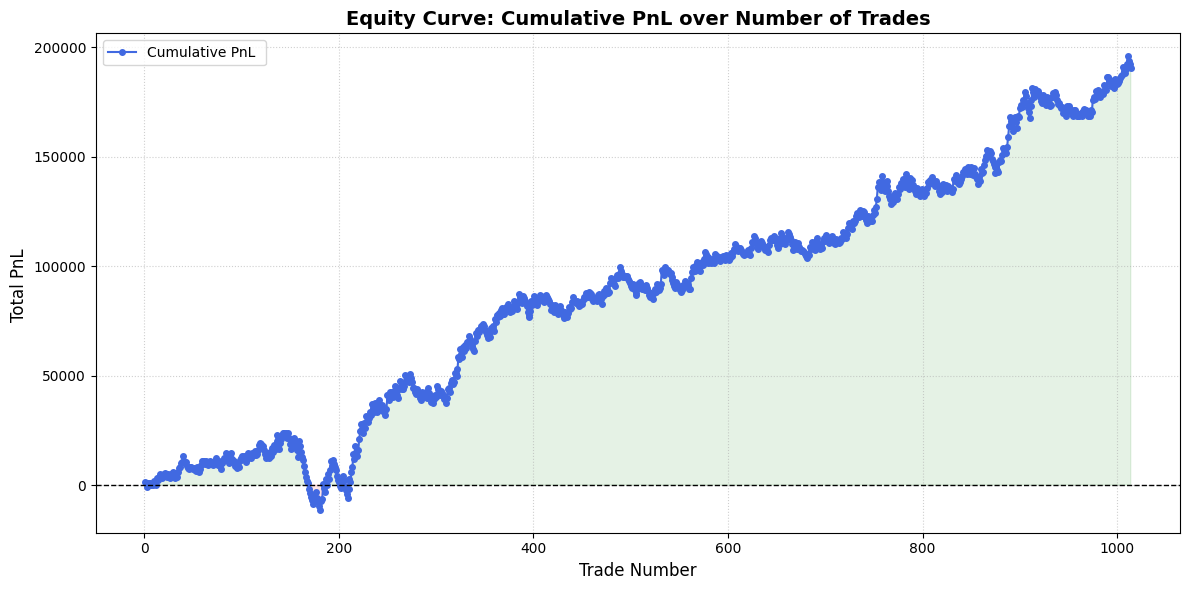

In [41]:
plot_equity_curve(trades_df, mode="pnl") # raw pnl dollars graph